In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = 'datasetFolder/processed_dataset2.csv'  # Replace with your dataset path
data = pd.read_csv(file_path, encoding='latin-1')

# Rename columns for clarity
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Features and target
X = data['text']
y = data['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorization for Multinomial Naive Bayes
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Multinomial Naive Bayes
# mnb_model = MultinomialNB()
# mnb_model.fit(X_train_tfidf, y_train)
# y_pred_mnb = mnb_model.predict(X_test_tfidf)

# Evaluation for Multinomial Naive Bayes
# print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_mnb))
# print("\nClassification Report:\n", classification_report(y_test, y_pred_mnb))

# Vectorization for Bernoulli Naive Bayes
binary_vectorizer = CountVectorizer(binary=True)
X_train_binary = binary_vectorizer.fit_transform(X_train)
X_test_binary = binary_vectorizer.transform(X_test)

# Bernoulli Naive Bayes
bnb_model = BernoulliNB()
bnb_model.fit(X_train_binary, y_train)
y_pred_bnb = bnb_model.predict(X_test_binary)

# Evaluation for Bernoulli Naive Bayes
# print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_bnb))
# print("\nClassification Report:\n", classification_report(y_test, y_pred_bnb))

In [15]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from termcolor import colored


# Calculate error metrics for Bernoulli Naive Bayes
mae_bnb = mean_absolute_error(y_test, y_pred_bnb)
mse_bnb = mean_squared_error(y_test, y_pred_bnb)
rmse_bnb = np.sqrt(mse_bnb)

# Accuracy for Bernoulli Naive Bayes
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(colored(f"Bernoulli Naive Bayes Accuracy: {accuracy_bnb:.4f}", 'green'))

# Error metrics
print(colored(f"\nMean Absolute Error (MAE): {mae_bnb:.4f}", 'red'))
print(colored(f"Mean Squared Error (MSE): {mse_bnb:.4f}", 'magenta'))
print(colored(f"Root Mean Squared Error (RMSE): {rmse_bnb:.4f}\n\n", 'magenta'))

# Classification Report
report_bnb = classification_report(y_test, y_pred_bnb)
print(colored("\nClassification Report:", 'blue'))
print(colored(report_bnb, 'white'))


Bernoulli Naive Bayes Accuracy: 0.7640

Mean Absolute Error (MAE): 0.2360
Mean Squared Error (MSE): 0.2360
Root Mean Squared Error (RMSE): 0.4858



Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77    159444
           1       0.78      0.74      0.76    160455

    accuracy                           0.76    319899
   macro avg       0.76      0.76      0.76    319899
weighted avg       0.76      0.76      0.76    319899



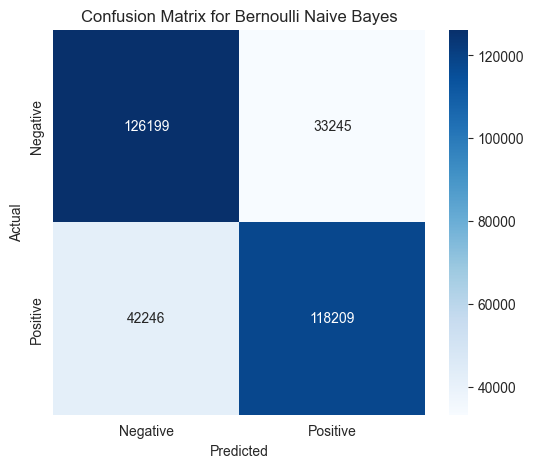

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for Bernoulli Naive Bayes
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Bernoulli Naive Bayes')
plt.show()
